# Concept Drift Detection Evaluation

This notebook evaluates the concept drift detection system on electricity market data.

In [1]:
import sys
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

sys.path.append("../src")

from data_stream import DataStream
from drift_detection import DriftDetector, MultiFeatureDriftDetector
from model import OnlineModel, EnsembleModel
from retrain import RetrainingStrategy, AdaptiveEnsemble

## 1. Load and Explore Data

In [2]:
# Load dataset
df = pd.read_csv("../data/electricity_market_dataset.csv")

print(f"Dataset shape: {df.shape}")
print(f"\nColumns:")
print(df.columns.tolist())
print(f"\nDate range: {df['Timestamp'].min()} to {df['Timestamp'].max()}")

Dataset shape: (61368, 27)

Columns:
['Timestamp', 'Historical_Electricity_Prices', 'Projected_Electricity_Prices', 'Inflation_Rates', 'GDP_Growth_Rate', 'Energy_Market_Demand', 'Renewable_Investment_Costs', 'Fossil_Fuel_Costs', 'Electricity_Export_Prices', 'Market_Elasticity', 'Subsidies', 'Energy_Production_By_Solar', 'Energy_Production_By_Wind', 'Energy_Production_By_Coal', 'Energy_Storage_Capacity', 'GHG_Emissions', 'Renewable_Penetration_Rate', 'Regulatory_Policies', 'Energy_Access_Data', 'LCOE', 'ROI', 'Net_Present_Value', 'Population_Growth', 'Optimal_Energy_Mix', 'Electricity_Price_Forecast', 'Project_Risk_Analysis', 'Investment_Feasibility']

Date range: 2018-01-01 00:00:00 to 2024-12-31 23:00:00


In [3]:
# Display basic statistics
df.describe()

,Historical_Electricity_Prices,Projected_Electricity_Prices,Inflation_Rates,GDP_Growth_Rate,Energy_Market_Demand,Renewable_Investment_Costs,Fossil_Fuel_Costs,Electricity_Export_Prices,Market_Elasticity,Subsidies,...,Energy_Storage_Capacity,GHG_Emissions,Renewable_Penetration_Rate,LCOE,ROI,Net_Present_Value,Population_Growth,Optimal_Energy_Mix,Electricity_Price_Forecast,Investment_Feasibility
count,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,...,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000
mean,85.000133,92.499865,2.499793,3.000193,3500.000178,80.000245,89.999970,55.000209,0.699947,9.999953,...,499.999709,400.000031,34.999616,49.999974,15.000232,2999.999528,1.029878,59.999764,124.999636,1.149706
std,20.207781,21.651668,0.579781,0.579561,866.046568,11.547427,5.773346,8.660411,0.125991,2.887450,...,173.209643,57.736405,8.660404,5.774092,2.887143,1154.729006,0.051432,5.773664,14.433939,0.208097
min,49.961967,54.899707,1.371817,1.840816,1999.968412,59.902353,79.912799,39.906512,0.331843,4.880353,...,199.923389,299.907257,19.916594,39.866893,9.827416,1000.009975,0.787569,49.831351,99.902578,0.636332
25%,67.498299,73.756672,1.999238,2.500159,2750.034414,70.002076,85.006844,47.492678,0.599755,7.499709,...,349.990197,349.994757,27.494940,44.996564,12.503373,1999.981113,0.994916,55.003158,112.500990,0.974866
50%,85.004525,92.499198,2.500932,3.000710,3499.986313,79.995556,90.000237,54.991897,0.700034,10.003353,...,500.024111,399.998383,34.998461,50.002322,15.000669,3000.000295,1.029783,59.997292,124.998010,1.149406
75%,102.504051,111.254199,3.000532,3.500458,4250.039623,89.996144,94.996444,62.501004,0.799812,12.503391,...,649.995991,449.989600,42.499383,54.994686,17.498372,3999.940143,1.064242,65.002729,137.497524,1.324851
max,120.098280,130.099068,3.651361,4.161202,5000.017293,100.119245,100.090504,70.143488,1.059527,15.147859,...,799.997144,500.080877,50.083318,60.116008,20.189480,4999.960646,1.233942,70.193535,150.114096,1.658918


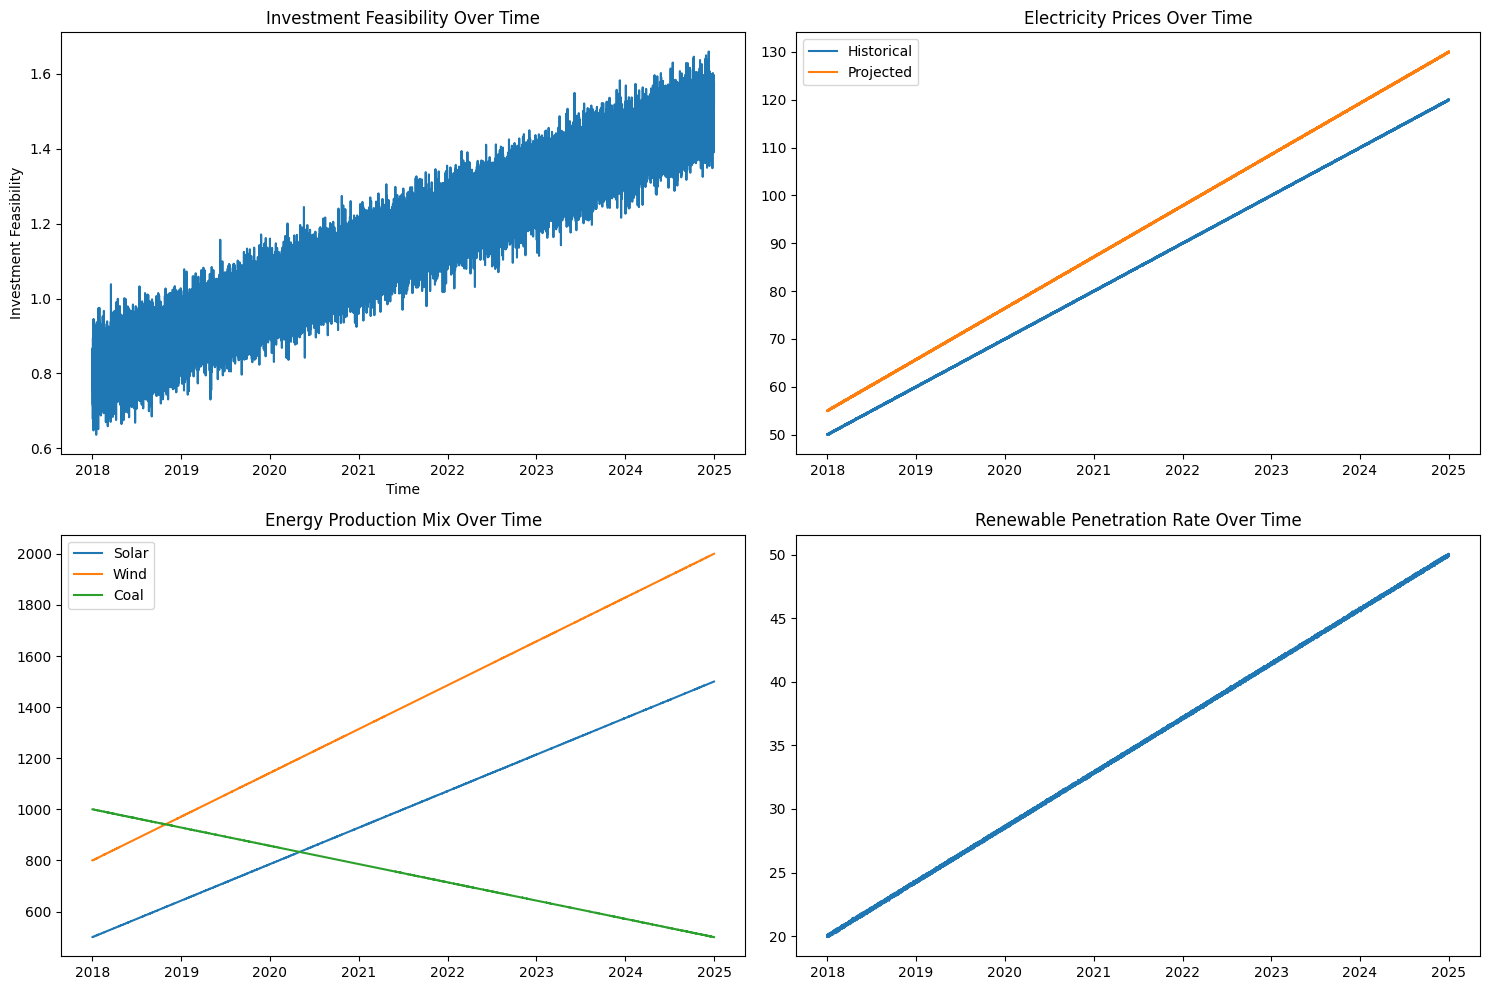

In [4]:
# Plot target variable over time
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Investment Feasibility
axes[0, 0].plot(df['Timestamp'], df['Investment_Feasibility'])
axes[0, 0].set_title('Investment Feasibility Over Time')
axes[0, 0].set_xlabel('Time')
axes[0, 0].set_ylabel('Investment Feasibility')

# Electricity Prices
axes[0, 1].plot(df['Timestamp'], df['Historical_Electricity_Prices'], label='Historical')
axes[0, 1].plot(df['Timestamp'], df['Projected_Electricity_Prices'], label='Projected')
axes[0, 1].set_title('Electricity Prices Over Time')
axes[0, 1].legend()

# Energy Production Mix
axes[1, 0].plot(df['Timestamp'], df['Energy_Production_By_Solar'], label='Solar')
axes[1, 0].plot(df['Timestamp'], df['Energy_Production_By_Wind'], label='Wind')
axes[1, 0].plot(df['Timestamp'], df['Energy_Production_By_Coal'], label='Coal')
axes[1, 0].set_title('Energy Production Mix Over Time')
axes[1, 0].legend()

# Renewable Penetration
axes[1, 1].plot(df['Timestamp'], df['Renewable_Penetration_Rate'])
axes[1, 1].set_title('Renewable Penetration Rate Over Time')

plt.tight_layout()
plt.savefig('../outputs/graphs/data_overview.png', dpi=150)
plt.show()

## 2. Test DataStream Component

In [5]:
# Test DataStream
stream = DataStream("../data/electricity_market_dataset.csv")

print("Testing DataStream:")
count = 0
samples = []
while stream.has_more_data() and count < 5:
    row = stream.get_next_instance()
    samples.append(row)
    print(f"Sample {count}: Investment_Feasibility={row['Investment_Feasibility']:.4f}")
    count += 1

Testing DataStream:
Sample 0: Investment_Feasibility=0.8360
Sample 1: Investment_Feasibility=0.7567
Sample 2: Investment_Feasibility=0.8018
Sample 3: Investment_Feasibility=0.8062
Sample 4: Investment_Feasibility=0.8214


## 3. Test Model Component

In [6]:
# Test different model types
model_types = ['linear', 'tree', 'adaptive_tree']

for model_type in model_types:
    print(f"\nTesting {model_type} model...")
    model = OnlineModel(model_type=model_type)
    
    # Create a fresh stream
    stream = DataStream("../data/electricity_market_dataset.csv")
    
    # Train on first 100 samples
    for _ in range(100):
        if stream.has_more_data():
            row = stream.get_next_instance()
            model.learn_one(row)
    
    # Test prediction
    if stream.has_more_data():
        test_row = stream.get_next_instance()
        pred = model.predict_one(test_row)
        actual = model._get_target(test_row)
        print(f"  Prediction: {pred:.4f}, Actual: {actual:.4f}, Error: {abs(pred-actual):.4f}")


Testing linear model...


  Prediction: 0.8746, Actual: 0.7483, Error: 0.1263

Testing tree model...


  Prediction: 0.7933, Actual: 0.7483, Error: 0.0450

Testing adaptive_tree model...


  Prediction: 0.7929, Actual: 0.7483, Error: 0.0446


## 4. Test Drift Detection

Testing Drift Detector...
  Drift detected at sample 543

Total drift detections: 1


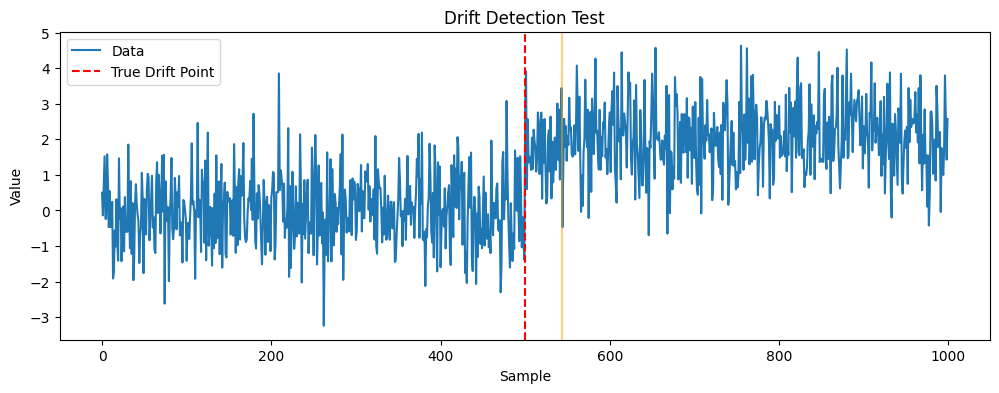

In [7]:
# Test drift detection with synthetic drift
print("Testing Drift Detector...")

# Simulate data with drift
np.random.seed(42)
n_samples = 1000

# First half: mean=0, std=1
# Second half: mean=2, std=1 (drift)
data_part1 = np.random.normal(0, 1, n_samples//2)
data_part2 = np.random.normal(2, 1, n_samples//2)
data = np.concatenate([data_part1, data_part2])

# Test ADWIN
adwin = DriftDetector(detector_type='adwin')
drift_points = []

for i, val in enumerate(data):
    # Simulate prediction error
    predicted = 0  # Baseline predictor
    if adwin.update(val, predicted):
        drift_points.append(i)
        print(f"  Drift detected at sample {i}")

print(f"\nTotal drift detections: {len(drift_points)}")

# Visualize
plt.figure(figsize=(12, 4))
plt.plot(data, label='Data')
plt.axvline(x=n_samples//2, color='red', linestyle='--', label='True Drift Point')
for dp in drift_points:
    plt.axvline(x=dp, color='orange', alpha=0.5)
plt.legend()
plt.title('Drift Detection Test')
plt.xlabel('Sample')
plt.ylabel('Value')
plt.savefig('../outputs/graphs/drift_detection_test.png', dpi=150)
plt.show()

## 5. Full Pipeline Test

In [8]:
# Run a small-scale test of the full pipeline
print("Running full pipeline test...")

stream = DataStream("../data/electricity_market_dataset.csv")
model = OnlineModel(model_type='adaptive_tree')
drift_detector = DriftDetector(detector_type='adwin')
retrainer = RetrainingStrategy(model, strategy='window', window_size=1000, warmup_size=500)

predictions = []
actuals = []
errors = []
drift_points = []
metrics_log = []

n_test = 5000
warmup = 500

for i in range(n_test):
    if not stream.has_more_data():
        break
    
    row = stream.get_next_instance()
    y_true = model._get_target(row)
    
    if i < warmup:
        model.learn_one(row)
        retrainer.add_sample(row)
    else:
        y_pred = model.predict_one(row)
        predictions.append(y_pred)
        actuals.append(y_true)
        
        error = abs(y_true - y_pred)
        errors.append(error)
        
        if drift_detector.update(y_true, y_pred):
            drift_points.append(i)
            print(f"Drift at sample {i}, error={error:.4f}")
            retrainer.on_drift_detected(i)
        
        model.learn_one(row)
        retrainer.add_sample(row)
        
        if (i - warmup) % 500 == 0:
            recent_mae = np.mean(errors[-500:])
            print(f"Sample {i}: MAE={recent_mae:.4f}")
            metrics_log.append({'sample': i, 'mae': recent_mae})

print(f"\nTest complete!")
print(f"Drift points detected: {len(drift_points)}")
print(f"Final MAE: {np.mean(errors):.4f}")

Running full pipeline test...


Sample 500: MAE=0.0489


Sample 1000: MAE=0.0406


Sample 1500: MAE=0.0403


Sample 2000: MAE=0.0412


...

Sample 3000: MAE=0.0408


Sample 3500: MAE=0.0437


Sample 4000: MAE=0.0441


Sample 4500: MAE=0.0432



Test complete!
Drift points detected: 0
Final MAE: 0.0421


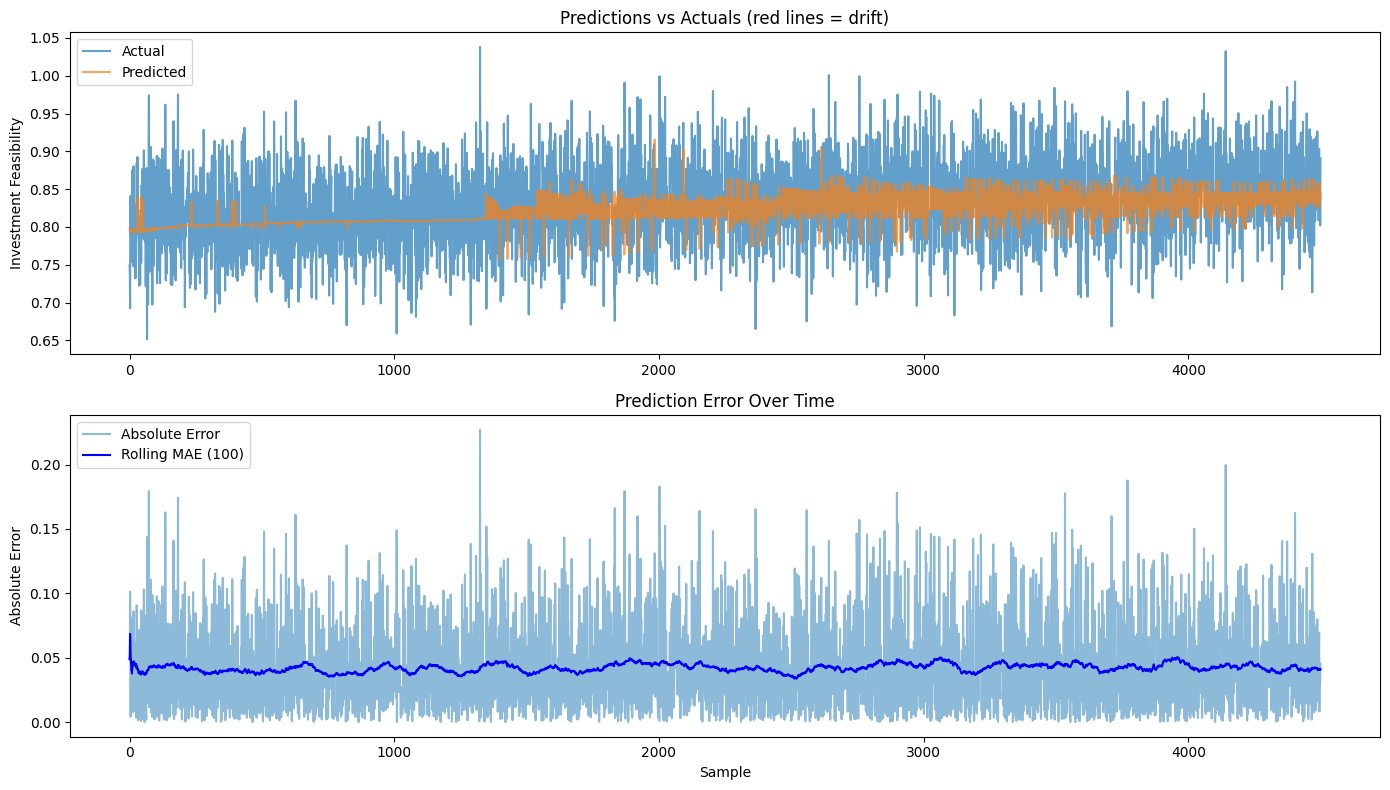

In [9]:
# Visualize results
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: Predictions vs Actuals
x_vals = range(len(predictions))
axes[0].plot(x_vals, actuals, label='Actual', alpha=0.7)
axes[0].plot(x_vals, predictions, label='Predicted', alpha=0.7)
for dp in drift_points:
    axes[0].axvline(x=dp-warmup, color='red', linestyle='--', alpha=0.5)
axes[0].set_title('Predictions vs Actuals (red lines = drift)')
axes[0].legend()
axes[0].set_ylabel('Investment Feasibility')

# Plot 2: Error over time
axes[1].plot(x_vals, errors, label='Absolute Error', alpha=0.5)
# Plot rolling mean
window = 100
rolling_mae = [np.mean(errors[max(0, i-window):i+1]) for i in range(len(errors))]
axes[1].plot(x_vals, rolling_mae, label=f'Rolling MAE ({window})', color='blue')
for dp in drift_points:
    axes[1].axvline(x=dp-warmup, color='red', linestyle='--', alpha=0.5)
axes[1].set_title('Prediction Error Over Time')
axes[1].set_xlabel('Sample')
axes[1].set_ylabel('Absolute Error')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/graphs/pipeline_test_results.png', dpi=150)
plt.show()

## 6. Run Complete Pipeline from CLI

In [10]:
# Run the main pipeline
!cd ../src && python main.py --model adaptive_tree --detector adwin --max-samples 10000

Concept Drift Detection Pipeline
Data: data/electricity_market_dataset.csv
Model: adaptive_tree, Drift Detector: adwin
Error loading file: [Errno 2] No such file or directory: 'data/electricity_market_dataset.csv'

Processing samples...

Pipeline Complete
  No valid predictions made

Results saved to: outputs\results_adaptive_tree_adwin_20260418_015445.json


Results Summary:
  Model: linear
  Detector: page_hinkley
  Total samples: 20000
  Drift count: 0
  Final MAE: 0.0727
  Final RMSE: 0.0911


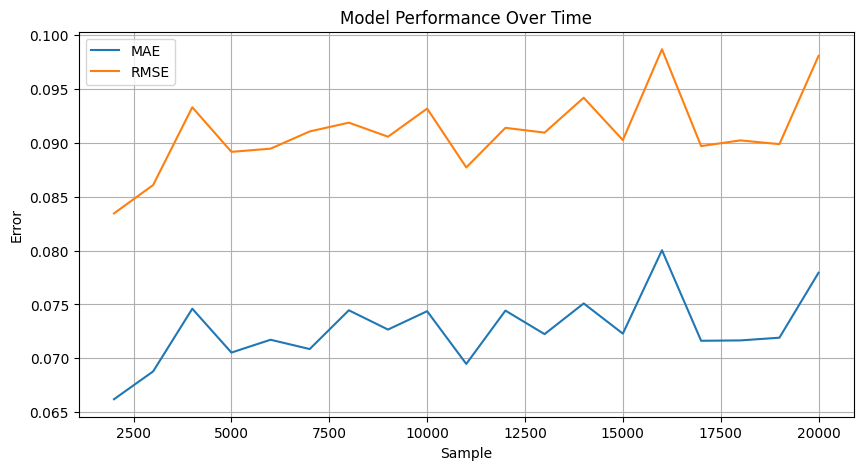

In [11]:
# Load and visualize results
import glob

# Find latest results file
result_files = glob.glob('../outputs/results_*.json')
if result_files:
    latest_file = max(result_files, key=os.path.getctime)
    with open(latest_file, 'r') as f:
        results = json.load(f)
    
    print("Results Summary:")
    print(f"  Model: {results['config']['model_type']}")
    print(f"  Detector: {results['config']['detector_type']}")
    print(f"  Total samples: {results['summary']['total_samples']}")
    print(f"  Drift count: {results['summary']['drift_count']}")
    print(f"  Final MAE: {results['summary']['final_mae']:.4f}")
    print(f"  Final RMSE: {results['summary']['final_rmse']:.4f}")
    
    # Plot metrics history
    if results['metrics_history']:
        mh = results['metrics_history']
        samples = [m['sample'] for m in mh]
        mae_values = [m['mae'] for m in mh]
        rmse_values = [m['rmse'] for m in mh]
        
        plt.figure(figsize=(10, 5))
        plt.plot(samples, mae_values, label='MAE')
        plt.plot(samples, rmse_values, label='RMSE')
        plt.xlabel('Sample')
        plt.ylabel('Error')
        plt.title('Model Performance Over Time')
        plt.legend()
        plt.grid(True)
        plt.savefig('../outputs/graphs/performance_over_time.png', dpi=150)
        plt.show()
else:
    print("No results files found. Run the pipeline first.")

## 7. Model Comparison

In [12]:
# Run comparison (this will take longer)
# !cd ../src && python main.py --compare --max-samples 5000

In [13]:
# Load comparison results
comparison_files = glob.glob('../outputs/comparison_*.json')
if comparison_files:
    latest_comparison = max(comparison_files, key=os.path.getctime)
    with open(latest_comparison, 'r') as f:
        comparison = json.load(f)
    
    # Create comparison table
    results_data = []
    for item in comparison:
        results_data.append({
            'Model': item['model'],
            'Detector': item['detector'],
            'MAE': item['results']['summary']['final_mae'],
            'RMSE': item['results']['summary']['final_rmse'],
            'Drifts': item['results']['summary']['drift_count']
        })
    
    comparison_df = pd.DataFrame(results_data)
    print(comparison_df.to_string(index=False))
    
    # Visualize comparison
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # MAE comparison
    comparison_df.boxplot(column='MAE', by='Model', ax=axes[0])
    axes[0].set_title('MAE by Model Type')
    axes[0].set_ylabel('Mean Absolute Error')
    
    # Drift detections
    comparison_df.boxplot(column='Drifts', by='Detector', ax=axes[1])
    axes[1].set_title('Drift Detections by Detector Type')
    axes[1].set_ylabel('Number of Drifts')
    
    plt.suptitle('')  # Remove automatic title
    plt.tight_layout()
    plt.savefig('../outputs/graphs/model_comparison.png', dpi=150)
    plt.show()
else:
    print("No comparison files found. Run with --compare first.")

No comparison files found. Run with --compare first.


## 8. Analyze Feature Importance

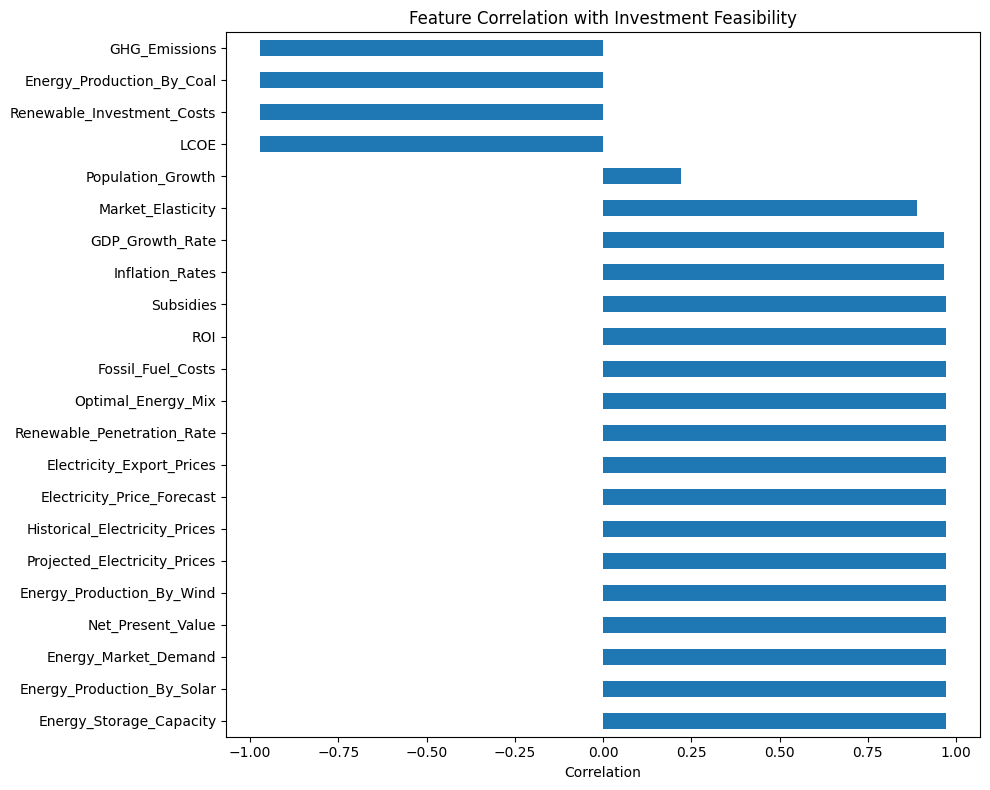

In [14]:
# Analyze feature correlations with target
numeric_features = df.select_dtypes(include=[np.number]).columns
correlations = df[numeric_features].corr()['Investment_Feasibility'].sort_values(ascending=False)

plt.figure(figsize=(10, 8))
correlations.drop('Investment_Feasibility').plot(kind='barh')
plt.title('Feature Correlation with Investment Feasibility')
plt.xlabel('Correlation')
plt.tight_layout()
plt.savefig('../outputs/graphs/feature_correlations.png', dpi=150)
plt.show()

## Summary

This notebook demonstrated:
1. Data exploration and visualization
2. Component testing (DataStream, Model, Drift Detection)
3. Full pipeline execution
4. Results analysis and visualization

The concept drift detection system is now complete and ready for use on electricity market data.